In [4]:
# Import the module
import importlib
import IsovizPy as ja
import pandas as pd
import gffutils

In [5]:
# After making changes to IsovizPy, reload it (mostly for testing purposes)
importlib.reload(ja)

<module 'IsovizPy' from '/gpfs/commons/home/kisaev/Leaflet-private/src/visualization/IsovizPy.py'>

In [6]:
# Load data and create the database (note this may take 1-2 minutes - do this once!)
gtf_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf"  
fasta_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/fasta/genome.fa"

In [7]:
# Path to the database file created previously
db_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/TabulaSenis/LeafletFA_analysis/gencode.vM19"

# Load the database
db = gffutils.FeatureDB(db_path, keep_order=True)

In [8]:
# Define the junctions and target format for conversion
junctions = [
    ("chr11", 69919336, 69921162, "-"),
    ("chr11", 69919336, 69920800, "-"),
    ("chr11", 69919336, 69920340, "-"),
    ("chr11", 69920434, 69921162, "-"),
    ("chr11", 69919336, 69921023, "-")
]

# If you have usage ratios, you can also specify those here otherwise, make a column in data called "usage_ratio" and make all values 0 to turn off this functionality 
usage_ratios = [0, 0, 0, 0, 0]

# Adjust the 'usage_ratio' values to be rounded to the nearest whole number for percentage format
data = {
    'junction_id': [f"{chrom}_{start}_{end}_{strand}" for chrom, start, end, strand in junctions],
    'Cluster': [55951] * len(junctions),  # Assign all to a single cluster for simplicity
    'usage_ratio': [round(ratio) for ratio in usage_ratios]  # Round to the nearest whole number
}

In [9]:
junctions = [("chr16", 20540813, 20540974, "+"),
    ("chr16", 20540415, 20540974, "+"),
    ("chr16", 20540415, 20540807, "+")]

usage_ratios = [0, 0, 0]

In [10]:
junctions = [("chr4" , 129601243, 129602194, "+"),
    ("chr4" , 129601134, 129607086, "+"),
    ("chr4" , 129602261, 129607086, "+"),
    ("chr4" , 129601134, 129601869, "+"),
    ("chr4" , 129601134, 129602194, "+"),
    ("chr4" , 129601533, 129601869, "+"),
    ("chr4" , 129601961, 129602194, "+"),
    ("chr4" , 129601134, 129601406, "+"),
    ("chr4" , 129601243, 129601869, "+"),
    ("chr4" , 129601533, 129602194, "+"),
    ("chr4" , 129601243, 129607086, "+"),
    ("chr4" , 129601243, 129601406, "+"),
    ("chr4" , 129601134, 129602221, "+")]

usage_ratios = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [11]:
# Adjust the 'usage_ratio' values to be rounded to the nearest whole number for percentage format
data = {
    'junction_id': [f"{chrom}_{start}_{end}_{strand}" for chrom, start, end, strand in junctions],
    'Cluster': [55951] * len(junctions),  # Assign all to a single cluster for simplicity
    'usage_ratio': [round(ratio) for ratio in usage_ratios]  # Round to the nearest whole number
}

In [12]:
splice_adata_var = pd.DataFrame(data)
print(splice_adata_var)

                   junction_id  Cluster  usage_ratio
0   chr4_129601243_129602194_+    55951            0
1   chr4_129601134_129607086_+    55951            0
2   chr4_129602261_129607086_+    55951            0
3   chr4_129601134_129601869_+    55951            0
4   chr4_129601134_129602194_+    55951            0
5   chr4_129601533_129601869_+    55951            0
6   chr4_129601961_129602194_+    55951            0
7   chr4_129601134_129601406_+    55951            0
8   chr4_129601243_129601869_+    55951            0
9   chr4_129601533_129602194_+    55951            0
10  chr4_129601243_129607086_+    55951            0
11  chr4_129601243_129601406_+    55951            0
12  chr4_129601134_129602221_+    55951            0


In [13]:
# Convert junction_ids to format that can easily be overlapped with transcript coordinates stored in our database 
splice_junctions = ja.convert_junction_ids(splice_adata_var)
print(splice_junctions)

[{'chrom': 'chr4', 'start': 129601243, 'end': 129602194, 'name': 'junction_1', 'strand': '+', 'usage_ratio': 0}, {'chrom': 'chr4', 'start': 129601134, 'end': 129607086, 'name': 'junction_2', 'strand': '+', 'usage_ratio': 0}, {'chrom': 'chr4', 'start': 129602261, 'end': 129607086, 'name': 'junction_3', 'strand': '+', 'usage_ratio': 0}, {'chrom': 'chr4', 'start': 129601134, 'end': 129601869, 'name': 'junction_4', 'strand': '+', 'usage_ratio': 0}, {'chrom': 'chr4', 'start': 129601134, 'end': 129602194, 'name': 'junction_5', 'strand': '+', 'usage_ratio': 0}, {'chrom': 'chr4', 'start': 129601533, 'end': 129601869, 'name': 'junction_6', 'strand': '+', 'usage_ratio': 0}, {'chrom': 'chr4', 'start': 129601961, 'end': 129602194, 'name': 'junction_7', 'strand': '+', 'usage_ratio': 0}, {'chrom': 'chr4', 'start': 129601134, 'end': 129601406, 'name': 'junction_8', 'strand': '+', 'usage_ratio': 0}, {'chrom': 'chr4', 'start': 129601243, 'end': 129601869, 'name': 'junction_9', 'strand': '+', 'usage_rat

In [14]:
ja.check_splice_site_motifs(fasta_file, splice_junctions)

[{'chrom': 'chr4',
  'start': 129601243,
  'end': 129602194,
  'name': 'junction_1',
  'strand': '+',
  'usage_ratio': 0,
  'splice_motif': 'GT-AG',
  'donor_seq': 'GT',
  'acceptor_seq': 'AG'},
 {'chrom': 'chr4',
  'start': 129601134,
  'end': 129607086,
  'name': 'junction_2',
  'strand': '+',
  'usage_ratio': 0,
  'splice_motif': 'GT-AG',
  'donor_seq': 'GT',
  'acceptor_seq': 'AG'},
 {'chrom': 'chr4',
  'start': 129602261,
  'end': 129607086,
  'name': 'junction_3',
  'strand': '+',
  'usage_ratio': 0,
  'splice_motif': 'GT-AG',
  'donor_seq': 'GT',
  'acceptor_seq': 'AG'},
 {'chrom': 'chr4',
  'start': 129601134,
  'end': 129601869,
  'name': 'junction_4',
  'strand': '+',
  'usage_ratio': 0,
  'splice_motif': 'GT-AG',
  'donor_seq': 'GT',
  'acceptor_seq': 'AG'},
 {'chrom': 'chr4',
  'start': 129601134,
  'end': 129602194,
  'name': 'junction_5',
  'strand': '+',
  'usage_ratio': 0,
  'splice_motif': 'GT-AG',
  'donor_seq': 'GT',
  'acceptor_seq': 'AG'},
 {'chrom': 'chr4',
  'sta

In [15]:
# Check junction annotations
junction_annotation_results = ja.check_junction_annotation(splice_junctions, db)
print(junction_annotation_results)

# Extract unique transcript IDs from junction_labels
unique_transcripts = list({transcript for label in junction_annotation_results for transcript in label['transcripts']})
print(unique_transcripts)

100%|██████████| 13/13 [00:01<00:00,  8.13it/s]

[{'junction': 'chr4:129601243-129602194', 'strand': '+', 'label_5_prime': "annotated on 5'", 'label_3_prime': "annotated on 3'", 'position_off_5_prime': 0, 'position_off_3_prime': 1, 'transcripts': ['ENSMUST00000129515.7', 'ENSMUST00000151969.7', 'ENSMUST00000174350.7', 'ENSMUST00000152126.7', 'ENSMUST00000174610.1', 'ENSMUST00000135628.7', 'ENSMUST00000173937.7', 'ENSMUST00000172774.7', 'ENSMUST00000174073.7', 'ENSMUST00000173507.7', 'ENSMUST00000137090.7', 'ENSMUST00000144304.1']}, {'junction': 'chr4:129601134-129607086', 'strand': '+', 'label_5_prime': "annotated on 5'", 'label_3_prime': "annotated on 3'", 'position_off_5_prime': 0, 'position_off_3_prime': 1, 'transcripts': ['ENSMUST00000102591.9', 'ENSMUST00000145345.1', 'ENSMUST00000173758.7', 'ENSMUST00000181579.7', 'ENSMUST00000150110.7', 'ENSMUST00000173728.1', 'ENSMUST00000174819.7']}, {'junction': 'chr4:129602261-129607086', 'strand': '+', 'label_5_prime': "annotated on 5'", 'label_3_prime': "annotated on 3'", 'position_off_5

In [16]:
# Fetch transcript exon coordinates and determine plot boundaries
transcript_data = ja.fetch_transcripts_and_annotations(db, unique_transcripts)

In [17]:
# Get start and end coordinates for our plot 
region_start, region_end = ja.determine_region_boundaries(splice_junctions)

In [18]:
# Optionally - confirm whether your splice junctions fully annotate to known exons on 5' or 3' side! 
ja.check_junction_annotation(splice_junctions, db)

  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 96.78it/s]


[{'junction': 'chr4:129601243-129602194',
  'strand': '+',
  'label_5_prime': "annotated on 5'",
  'label_3_prime': "annotated on 3'",
  'position_off_5_prime': 0,
  'position_off_3_prime': 1,
  'transcripts': ['ENSMUST00000129515.7',
   'ENSMUST00000151969.7',
   'ENSMUST00000174350.7',
   'ENSMUST00000152126.7',
   'ENSMUST00000174610.1',
   'ENSMUST00000135628.7',
   'ENSMUST00000173937.7',
   'ENSMUST00000172774.7',
   'ENSMUST00000174073.7',
   'ENSMUST00000173507.7',
   'ENSMUST00000137090.7',
   'ENSMUST00000144304.1']},
 {'junction': 'chr4:129601134-129607086',
  'strand': '+',
  'label_5_prime': "annotated on 5'",
  'label_3_prime': "annotated on 3'",
  'position_off_5_prime': 0,
  'position_off_3_prime': 1,
  'transcripts': ['ENSMUST00000102591.9',
   'ENSMUST00000145345.1',
   'ENSMUST00000173758.7',
   'ENSMUST00000181579.7',
   'ENSMUST00000150110.7',
   'ENSMUST00000173728.1',
   'ENSMUST00000174819.7']},
 {'junction': 'chr4:129602261-129607086',
  'strand': '+',
  'label

Plot saved to Tmem234_no_usage_lines_20250128.pdf!


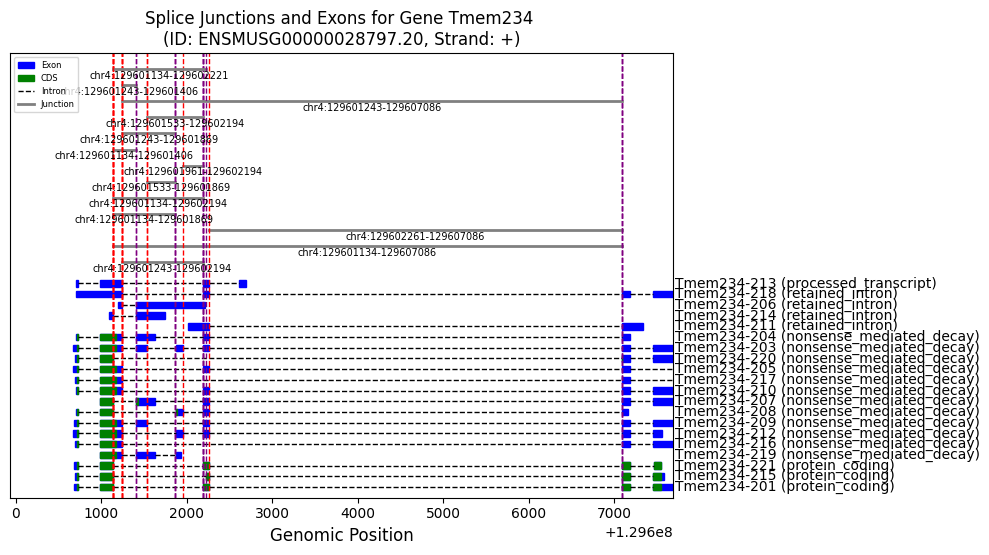

In [22]:
# Plot the annotations and splice junctions
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start-200, region_end-400, base_width=10, trans_height=0.2, show_usage=False, show_junc_lines=True)

In [ ]:
# Plot the annotations and splice junctions
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start-500, region_end-700, base_width=9, trans_height=0.5, show_usage=False, show_junc_lines=True)

In [ ]:
# Plot the annotations and splice junctions
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start-500, region_end-700, base_width=10, trans_height=0.8, show_usage=True, colorbar_pad=0.3 ,show_junc_lines=False)

In [ ]:
# Plot the annotations and splice junctions
ja.plot_exons_and_junctions(db, transcript_data, splice_junctions, region_start-500, region_end-700, base_width=10, trans_height=0.8, show_usage=True, colorbar_pad=0.3 ,show_junc_lines=True)

#### If you just want to visualize all of TREM2 isoforms without any specific splice junctions you can do the following:

In [ ]:
gene_name = "TREM2"

In [ ]:
transcript_ids = ja.fetch_transcripts_for_gene(db, gene_name)

# Step 2: Fetch transcript annotations
transcript_data = ja.fetch_transcripts_and_annotations(db, transcript_ids)
    
# Step 3: Determine region boundaries
region_start, region_end = ja.determine_region_boundaries_from_transcripts(transcript_data)

In [ ]:
# Step 4: Plot isoforms
ja.plot_isoforms(db, transcript_data, region_start-500, region_end+200, base_width=10, trans_height=0.3)